# Study Method Dataset

In this notebook we are going to explore the Dataset by checking the shape of the DataFrame, the target, the features and their distribuition and the correlation between the features and the target.

These are the library we will need.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Fetching the Dataset

In [3]:
df = pd.read_csv('../data/dataset.csv')

First of all we are gonna check the entire dataframe by using some useful Pandas' features.

The first is `describe`. It tells a lot of information about the DataFrame. With the attribute `include` and its value `all` it includes also the str columns.

In [4]:
df.describe(include='all')

,hours,stress,subject,study,preparation
count,10000.000000,10000.000000,10000,10000,10000.00000
unique,NaN,NaN,9,4,NaN
top,NaN,NaN,math,repeat,NaN
freq,NaN,NaN,1152,3606,NaN
mean,9.954550,5.517100,NaN,NaN,5.98147
std,5.735006,2.032024,NaN,NaN,2.30434
min,0.000000,1.000000,NaN,NaN,1.00000
25%,5.000000,4.000000,NaN,NaN,4.20000
50%,9.900000,6.000000,NaN,NaN,6.10000
75%,14.800000,7.000000,NaN,NaN,7.80000


With the attribute `shape` we can check the dimensions of the DataFrame

In [5]:
df.shape

(10000, 5)

With the attribute `head`, the program is going to print the first 5 rows of the DataFrame

In [6]:
df.head

<bound method NDFrame.head of       hours  stress           subject       study  preparation
0       7.1       7           history        read          4.1
1       2.2       9        philosophy        read          1.9
2       8.4       6  computer_science        read          4.8
3      14.5       4           italian  flashcards          9.2
4       2.1       5           history  flashcards          3.6
...     ...     ...               ...         ...          ...
9995   11.5       4              math  flashcards          7.8
9996    3.9       8           history      repeat          5.4
9997   11.9       6               art  flashcards         10.0
9998   15.1       3           english      repeat          8.8
9999    2.8       8           history      repeat          2.3

[10000 rows x 5 columns]>

With the attribute `tail` we are going to check the last five rows of the dataset

In [7]:
df.tail

<bound method NDFrame.tail of       hours  stress           subject       study  preparation
0       7.1       7           history        read          4.1
1       2.2       9        philosophy        read          1.9
2       8.4       6  computer_science        read          4.8
3      14.5       4           italian  flashcards          9.2
4       2.1       5           history  flashcards          3.6
...     ...     ...               ...         ...          ...
9995   11.5       4              math  flashcards          7.8
9996    3.9       8           history      repeat          5.4
9997   11.9       6               art  flashcards         10.0
9998   15.1       3           english      repeat          8.8
9999    2.8       8           history      repeat          2.3

[10000 rows x 5 columns]>

We can also check the types of values inside the DataFrame by using the object `dtypes`

In [8]:
df.dtypes

hours          float64
stress           int64
subject            str
study              str
preparation    float64
dtype: object

We can see that the type of two columns are str, that stands as `string`, so we will need to do the one-hot-econding to transform this types in something that the linear regression model can actually understands.

The last thing we are going to do is checking for missing values.

In [9]:
df.isnull()

,hours,stress,subject,study,preparation
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
9995,False,False,False,False,False
9996,False,False,False,False,False
9997,False,False,False,False,False
9998,False,False,False,False,False


In this case there aren't any.

Now that we have understood the structure of the dataset, we will observe the feature and the target of this ML model.

In [10]:
features = list(df.columns)
print(features)

['hours', 'stress', 'subject', 'study', 'preparation']


In this dataset the target is the feature named 'preparation'

Now that we have fetched all the features we can calculate their correlation with the target and plotting the graphics. The function `corr` will help us do just that. But, as we saw before, now is the moment to do the one-hot-encoding. The Pandas' function `get_dummies()` is going to do the work for us. The attribute `drop_first` will eliminate a column that is not going to be useful to us.

In [11]:
df_encoded = pd.get_dummies(df, columns=['subject', 'study'], drop_first=True)

In [12]:
correlations = df_encoded.corr()['preparation'].drop('preparation')
correlations = correlations.sort_values()
print(correlations)

stress                     -0.500129
study_read                 -0.296420
subject_math               -0.138252
subject_physics            -0.132939
subject_science            -0.096665
subject_philosophy         -0.027014
study_repeat               -0.017541
subject_history             0.049083
subject_italian             0.058586
subject_computer_science    0.115547
subject_english             0.116933
study_flashcards            0.360943
hours                       0.845745
Name: preparation, dtype: float64


The target variable is strongly influenced by study hours, while categorical features provide minor contributions.

Now we are going to plot the features with the highest impact on the target as a function of the target.

Text(0, 0.5, 'hours')

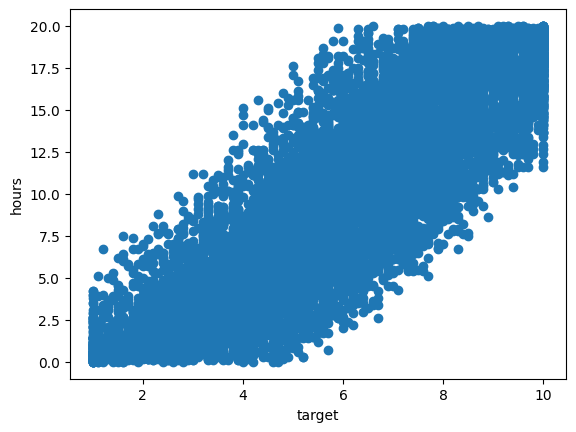

In [17]:
x = df_encoded['preparation']
y_1 = df_encoded['hours']

plt.scatter(x, y_1)
plt.xlabel('target')
plt.ylabel('hours')

This graphic confirms that the correlation between target and hours is very high. In addition, this distribution show us that we can produce a ML prevision model based on Linear Regression.

Text(0, 0.5, 'stress')

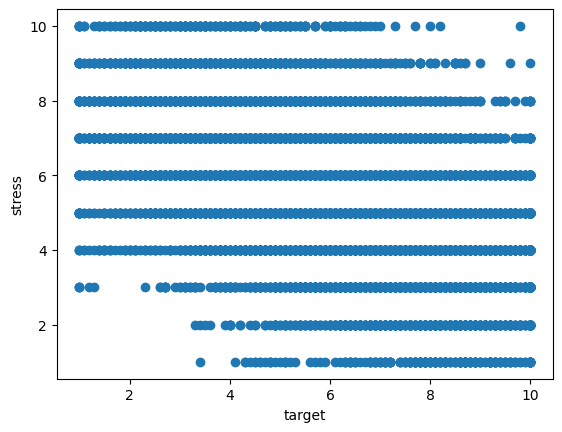

In [14]:
y_2 = df_encoded['stress']

plt.scatter(x, y_2)
plt.xlabel('target')
plt.ylabel('stress')

In this graphic we should focus on the two extremis of stress. If it is very high the target is quite low, as a result, if the target is very high there is no high stress.

Text(0, 0.5, 'flashcards')

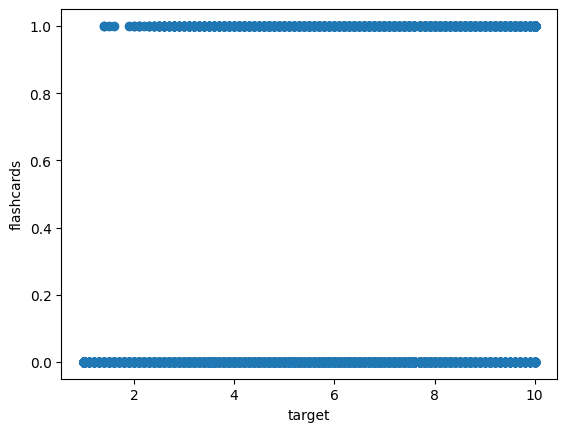

In [15]:
y_3 = df_encoded['study_flashcards']

plt.scatter(x, y_3)
plt.xlabel('target')
plt.ylabel('flashcards')

If flashcards equal to 1 (so that means that flashcards equal True) the target is slightly higher than flaschards equal false. This graphic matches the correletion value above.

Text(0, 0.5, 'read')

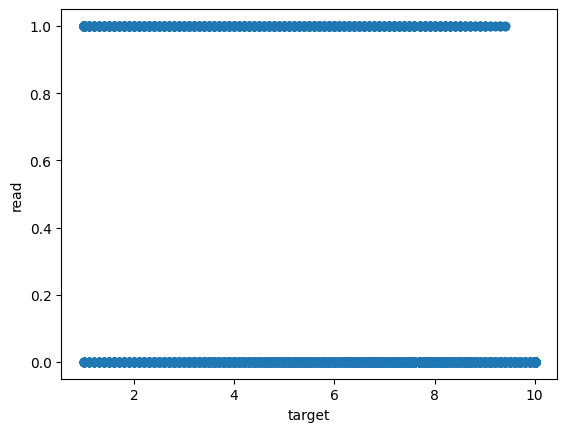

In [16]:
y_4 = df_encoded['study_read']

plt.scatter(x, y_4)
plt.xlabel('target')
plt.ylabel('read')

The correlation between target and read is negative and it has a minum impact. The flashcard method has quite the opposite impact so, in this distribution, we can see that this graphic is almost the opposite of the one above.